In [3]:
import matplotlib.gridspec as gridspec

import sys
original_sys_path = sys.path.copy()
sys.path.append('../utils')
from utils_visualization import *

In [234]:

from scqubits.settings import matplotlib_settings
import matplotlib as mpl
from matplotlib.axes import Axes
from scqubits.utils.plot_utils import _extract_kwargs_options
from numpy import ndarray
from scqubits.utils.misc import InfoBar, process_which
import scqubits.core.constants as constants
from scqubits.utils.spectrum_utils import (
    get_matrixelement_table,
    order_eigensystem,
    recast_esys_mapdata,
    standardize_sign,
)
from scqubits.utils.plot_utils import (
    _extract_kwargs_options,
    _process_options,
    add_numbers_to_axes,
    color_normalize,
    plot_potential_to_axes,
    plot_wavefunction_to_axes,
    scale_wavefunctions,
)
import scqubits.utils.misc as utils

@mpl.rc_context(matplotlib_settings)
def plot_wavefunction(
    qbt,
    which = 0,
    colors = None,
    mode= "real",
    esys = None,
    phi_grid = None,
    scaling = None,
    **kwargs,
):

    wavefunc_indices = process_which(which, qbt.truncated_dim)

    if esys is None:
        evals_count = max(wavefunc_indices) + 1
        esys = qbt.eigensys(evals_count=evals_count)
        evals, _ = esys
    else:
        evals, _ = esys

    if colors == None:
        colors = ['grey' for _ in range(len(evals))]

    energies = evals[list(wavefunc_indices)]

    phi_grid = phi_grid or qbt._default_grid
    potential_vals = qbt.potential(phi_grid.make_linspace())

    amplitude_modifier = constants.MODE_FUNC_DICT[mode]
    wavefunctions = []
    for wavefunc_index in wavefunc_indices:
        phi_wavefunc = qbt.wavefunction(
            esys, which=wavefunc_index, phi_grid=phi_grid
        )
        phi_wavefunc.amplitudes = standardize_sign(phi_wavefunc.amplitudes)
        phi_wavefunc.amplitudes = amplitude_modifier(phi_wavefunc.amplitudes)
        wavefunctions.append(phi_wavefunc)

    fig_ax = kwargs.get("fig_ax") or plt.subplots()
    kwargs["fig_ax"] = fig_ax
    kwargs = {
        **qbt.wavefunction1d_defaults(
            mode, evals, wavefunc_count=len(wavefunc_indices)  # type:ignore
        ),
        **kwargs,
    }
    # in merging the dictionaries in the previous line: if any duplicates,
    # later ones survive

    wavefunction1d(
        wavefunctions,
        potential_vals=potential_vals,  # type:ignore
        offset=energies,
        scaling=scaling,
        colors = colors,
        **kwargs,
    )
    return fig_ax

@mpl.rc_context(matplotlib_settings)
def wavefunction1d(
    wavefuncs,
    potential_vals,
    offset,
    scaling,
    colors,
    **kwargs,
):

    fig, axes = kwargs.get("fig_ax") or plt.subplots()

    offset_list = utils.to_list(offset)
    wavefunc_list = utils.to_list(wavefuncs)
    wavefunc_list = scale_wavefunctions(wavefunc_list, potential_vals, scaling)

    for wavefunction, energy_offset,color in zip(wavefunc_list, offset_list,colors):
        plot_wavefunction_to_axes(axes, wavefunction, energy_offset,color=color, **kwargs)

    x_vals = wavefunc_list[0].basis_labels
    plot_potential_to_axes(axes, x_vals, potential_vals, offset_list, **kwargs)

    _process_options(fig, axes, **kwargs)
    return fig, axes



@mpl.rc_context(matplotlib_settings)
def plot_wavefunction_to_axes(
    axes,
      wavefunction,
      energy_offset,
      color,
        **kwargs
) -> None:
    x_vals = wavefunction.basis_labels
    y_vals = energy_offset + wavefunction.amplitudes
    offset_vals = [energy_offset] * len(x_vals)

    axes.plot(x_vals, y_vals,color = color, alpha=0.5, **_extract_kwargs_options(kwargs, "plot"))
    axes.fill_between(
        x_vals, y_vals, offset_vals,color = color, alpha=0.5,where=(y_vals != offset_vals), interpolate=True
    )


@mpl.rc_context(matplotlib_settings)
def plot_potential_to_axes(
    axes: Axes,
    x_vals: ndarray,
    potential_vals: Union[ndarray, List[float]],
    offset_list: Union[ndarray, List[float]],
    **kwargs,
) -> None:
    y_min = np.min(potential_vals)
    y_max = np.max(offset_list)
    y_range = y_max - y_min

    y_max += 0.3 * y_range
    y_min = np.min(potential_vals) - 0.1 * y_range
    axes.set_ylim([y_min, y_max])

    axes.plot(
        x_vals, potential_vals, color="gray", **_extract_kwargs_options(kwargs, "plot")
    )


In [128]:
n_evals = 20
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.5, cutoff = 110,flux = 0,truncated_dim=n_evals)



In [30]:
omega_0 = qbt.eigenvals()[0]
omega_1 = qbt.eigenvals()[1]
omega_2 = qbt.eigenvals()[2]

omega_7 = qbt.eigenvals(10)[7]

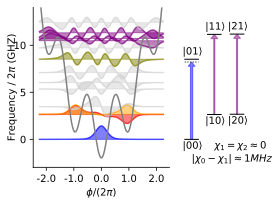

In [235]:


fig, axes = plt.subplots(1,2,figsize=(4,3), gridspec_kw={'width_ratios': [4, 2]})
plt.subplots_adjust(wspace=0)
ax = axes[0]
fig, ax = plot_wavefunction( qbt, which=list(range(13)),colors = ['blue','red','orange',
                                                                   'lightgrey','lightgrey','lightgrey','lightgrey', 'olive','lightgrey',
                                                                   'purple','purple','purple','lightgrey'
                                                                  ],
                                                                  fig_ax =(fig, ax ) )


ax.set_xticks(np.array([-2,-1,0,1,2])*2* np.pi)
current_ticks = ax.get_xticks()
modified_ticks = current_ticks /(2* np.pi)
ax.set_xticklabels([f'{val:.1f}' for val in modified_ticks])
ax.set_xlabel(r"$\phi/(2\pi)$")

ax.set_yticks(np.array([0,5,10,15])+omega_0)
current_ticks = ax.get_yticks()
modified_ticks = current_ticks - omega_0
ax.set_yticklabels([f'{val:.0f}' for val in modified_ticks])
ax.set_ylabel(rf"Frequency / $2\pi$ (GHZ)")
ax.yaxis.set_label_coords(-0.12, 0.5)
ax.set_ylim(-4,13)
# ax.plot([2.1*2* np.pi, 2.1*2* np.pi], [omega_0,omega_7],color = 'black',linewidth = 2)
# ax.plot([2.2*2* np.pi, 2.2*2* np.pi], [omega_1,omega_1 - omega_0 + omega_7],color = 'grey',linewidth = 1.5,linestyle='--')

ax =  axes[1]
ax.axis('off')
ax.set_ylim(axes[0].get_ylim())
ax.set_xlim((-0.5,2.5))
ax.margins(2)
for ql, x,freq in zip([0,1,2],
                 [0,1,2],
                 [omega_0,omega_1,omega_2]):
    ax.plot([x-0.3, x+0.3], [freq, freq], linewidth=1, color='black',linestyle = '-')
    ax.plot([x-0.3, x+0.3], [freq+omega_7-omega_0, freq+omega_7-omega_0], linewidth=1, color='black',linestyle = '-')
    ax.text(x-0.4,freq-1,rf"$|{ql}0\rangle$")
    ax.text(x-0.4,freq+omega_7-omega_0+0.5,rf"$|{ql}1\rangle$")
    if ql != 0:
        arrow = ax.arrow(x,freq, 0, omega_7-omega_0,width = 0.05,head_width=0.3,length_includes_head = True,alpha = 0.5)
        arrow.set(edgecolor = None,color='purple')
ax.plot([-0.3, +0.3], [omega_0+omega_7-omega_0 - 0.3, omega_0+omega_7-omega_0 - 0.3], linewidth=1, color='black',linestyle = 'dotted')
arrow =  ax.arrow(0,omega_0, 0, omega_7-omega_0-0.3,width = 0.1,head_width=0.3,length_includes_head = True,alpha = 0.5)
arrow.set(edgecolor = None,color='blue')

ax.text(1,-5+3,rf"$\chi_1 = \chi_2\approx 0$")
ax.text(0,-6.4+3,rf"$|\chi_0 - \chi_1| \approx 1MHz$")
plt.tight_layout()
fig.savefig('wavefuncs.pdf')


 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_29564/758117523.py: 147UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_29564/758117523.py: 147UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_29564/758117523.py: 180

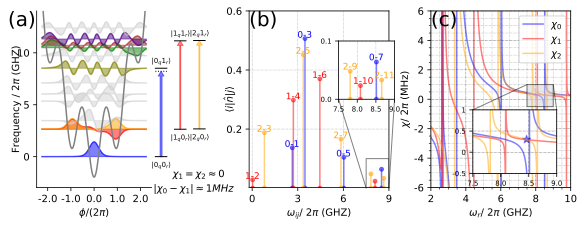

In [314]:
colors = ['blue','red','orange']
fig = plt.figure(figsize=(8,3),constrained_layout=False)
##################################################################
#
#
# first subplot
#
#
##################################################################
gs = fig.add_gridspec(nrows=1, ncols=2, wspace=0.0,width_ratios = [3, 1.5],left=0.05, right=0.35,)
def plot_wave_function(fig,ax):
    fig, ax = plot_wavefunction( qbt, which=list(range(13)),colors = ['blue','red','orange',
                                                                    'lightgrey','lightgrey','lightgrey','lightgrey', 'olive','lightgrey',
                                                                    'green','brown','indigo','lightgrey'
                                                                    ],
                                                                    fig_ax =(fig, ax ) )


    ax.set_xticks(np.array([-2,-1,0,1,2])*2* np.pi)
    current_ticks = ax.get_xticks()
    modified_ticks = current_ticks /(2* np.pi)
    ax.set_xticklabels([f'{val:.1f}' for val in modified_ticks])
    ax.set_xlabel(r"$\phi/(2\pi)$")

    ax.set_yticks(np.array([0,5,10,15])+omega_0)
    current_ticks = ax.get_yticks()
    modified_ticks = current_ticks - omega_0
    ax.set_yticklabels([f'{val:.0f}' for val in modified_ticks])
    ax.set_ylabel(rf"Frequency / $2\pi$ (GHZ)")
    ax.yaxis.set_label_coords(-0.135, 0.5)
    ax.set_ylim(-4,13)
    # ax.plot([2.1*2* np.pi, 2.1*2* np.pi], [omega_0,omega_7],color = 'black',linewidth = 2)
    # ax.plot([2.2*2* np.pi, 2.2*2* np.pi], [omega_1,omega_1 - omega_0 + omega_7],color = 'grey',linewidth = 1.5,linestyle='--')
plot_wave_function(fig,fig.add_subplot(gs[0]))
##################################################################
#
#
# second subplot
#
#
##################################################################
def plot_transition(ax):
    ax.axis('off')
    ax.set_ylim(axes[0].get_ylim())
    ax.set_xlim((-0.5,2.5))
    ax.margins(2)
    for ql, x,freq in zip([0,1,2],
                    [0,1,2],
                    [omega_0,omega_1,omega_2]):
        ax.plot([x-0.3, x+0.3], [freq, freq], linewidth=1, color='black',linestyle = '-')
        ax.plot([x-0.3, x+0.3], [freq+omega_7-omega_0, freq+omega_7-omega_0], linewidth=1, color='black',linestyle = '-')
        ax.text(x-0.5,freq-1,rf"$|{ql}_q 0_r\rangle$",size = 'x-small')
        ax.text(x-0.5,freq+omega_7-omega_0+0.5,rf"$|{ql}_q 1_r\rangle$",size = 'x-small')
        if ql != 0:
            arrow = ax.arrow(x,freq, 0, omega_7-omega_0,width = 0.05,head_width=0.3,length_includes_head = True,alpha = 0.5)
            arrow.set(edgecolor = None,color={1:'red',2:'orange'}[ql])
    ax.plot([-0.3, +0.3], [omega_0+omega_7-omega_0 - 0.3, omega_0+omega_7-omega_0 - 0.3], linewidth=1, color='black',linestyle = 'dotted')
    arrow =  ax.arrow(0,omega_0, 0, omega_7-omega_0-0.3,width = 0.1,head_width=0.3,length_includes_head = True,alpha = 0.5)
    arrow.set(edgecolor = None,color='blue')

    ax.text(0.6,-5+2,rf"$\chi_1 = \chi_2\approx 0$")
    ax.text(-0.4,-6.4+2,rf"$|\chi_0 - \chi_1| \approx 1MHz$")
plot_transition(fig.add_subplot(gs[1]))
plt.text(-0.25, 1, '(a)', transform=plt.subplot(gs[0]).transAxes, fontsize=20, va='top', color='black')




##################################################################
#
#
# third subplot
#
#
##################################################################

eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
def plot_fluxonium_transitions(ax,xlim,matrix=elements, energies=eigenvals,qls = [0,1,2],ylim = (2e-3,0.6) ,label_small_elements = False):
    k = 13#len(energies)
    for i in qls:
        for j in range(k): 
            if j >i:
                freq_ij = np.abs(energies[i] - energies[j])  # Frequency of the transition
                element_ij = abs(matrix[i, j])  # Matrix element
                
                if element_ij > 3e-3:
                    ax.plot([freq_ij, freq_ij], [0, element_ij], marker='o',  markersize=4,color=colors[i],alpha=0.5)
                if element_ij >= 3e-3:
                    x_loc = freq_ij  #- 0.1
                    y_loc = element_ij+0.003
                    if x_loc < xlim[-1] and x_loc > xlim[0] and y_loc > ylim[0] and y_loc <ylim[-1]:
                        if x_loc< 7.5:
                            ax.text(*(x_loc-0.5,y_loc), rf'{i}-{j}', size=9,color=colors[i])
                        elif label_small_elements:
                            ax.text(*(x_loc-0.2,y_loc), rf'{i}-{j}', size=9,color=colors[i])
    ax.set_xlabel(r'$\omega_{ij}$/ $2\pi$ (GHZ)')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='grey')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_ylabel(r'$\langle i|\hat{n}|j\rangle$')
    ax.yaxis.set_label_coords(-0.1, 0.5)
gs = fig.add_gridspec(nrows=1, ncols=2, wspace=0.3,width_ratios = [1, 1],left=0.42, right=0.98,)

ax = fig.add_subplot(gs[0])
plot_fluxonium_transitions(ax,xlim=(-0.2,9))
ax.set_yticks([0.2,0.4,0.6])
ax.set_xticks([0,3,6,9])
axins = ax.inset_axes(
    [0.64,0.5, 0.4,0.33])
plot_fluxonium_transitions(axins,xlim=(7.5,9),qls = [0,1,2],ylim = (2e-3,0.1) ,label_small_elements = True)
axins.set_xlabel('')
axins.set_yticks([0,0.1])
axins.tick_params(axis='both', which='major', labelsize=7)
axins.set_xticks([7.5,8,8.5,9])
axins.set_ylabel('')
ax.indicate_inset_zoom(axins, edgecolor="black")

##################################################################
#
#
# fourth subplot
#
#
##################################################################


def plot_sweep_Er(ax,matrix, evals,Er_list,qls = [0,1,2],ylim=(-1,1),participating_transitions = None,legend=True):
    num_evals =len(evals)
    if participating_transitions != None:
        for i in range(num_evals):
                for j in range(num_evals): 
                    if (i, j) not in participating_transitions and (j, i) not in participating_transitions:
                        matrix[i, j] = 0 
    for ql  in qls:
        shift_from_qubit_transition = []
        for Er in Er_list:
            shift_from_qubit_transition.append(sum([get_shift_accurate(matrix[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] )/100)
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = colors[ql],alpha=0.5)

    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlabel(rf'$\omega_r$/ $2\pi$ (GHZ)')
    ax.set_yticklabels([f'{val:.0f}' for val in ax.get_yticks() *1000])
    ax.set_ylabel(r'$\chi$/ $2\pi$ (MHz)')
    if legend:
        ax.legend(loc='upper right')
ax = fig.add_subplot(gs[1])
plot_sweep_Er(ax, elements,eigenvals,np.linspace(2,10,int(1e4)),qls = [0,1,2],ylim=(-0.006,0.006),
            participating_transitions = [(0,7),(1,10),(1,12),(2,9),(2,11),
                                           (0,1),(0,3),(0,5),
                                        (1,0),(1,2),(1,4),(1,6),
                                         (2,3),(2,5),(2,7)])
axins = ax.inset_axes(
    [0.3,0.08, 0.6,0.36])
plot_sweep_Er(axins, elements,eigenvals,np.linspace(7.5,9,int(5e3)),qls = [0,1,2],ylim=(-0.0005,0.001),
            participating_transitions = [(0,7),(1,10),(1,12),(2,9),(2,11),
                                           (0,1),(0,3),(0,5),
                                        (1,0),(1,2),(1,4),(1,6),
                                         (2,3),(2,5),(2,7)],legend=False)
axins.set_xlabel('')
axins.set_yticks([-0.0005,0,0.0005,0.001],labels=['-0.5','0','0.5','1'])
axins.set_ylabel('')
# axins.set_xticks([])
axins.tick_params(axis='both', which='major', labelsize=7)
axins.minorticks_off()
axins.scatter(8.46111172,0.0003, marker='*', color='blue', s=70,alpha=0.5)
ax.indicate_inset_zoom(axins, edgecolor="black",facecolor='lightgrey',)


plt.text(0, 1, '(b)', transform=plt.subplot(gs[0]).transAxes, fontsize=20, va='top', color='black')
plt.text(0, 1, '(c)', transform=plt.subplot(gs[1]).transAxes, fontsize=20, va='top', color='black')



plt.subplots_adjust(top=0.97,bottom=0.15)
plt.tight_layout()
fig.savefig('fig01.pdf')


In [127]:


colors = [(0.7, 0.6, 0.0), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]


linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

def plot_fluxonium_transitions(ax,matrix, energies,xlim,qls = [0,1,2],ylim = (2e-3,0.8) ):
        
    k = len(energies)  # Assuming matrix is k x k and energies is a list of length k
                        
    label_positions = []


    for i in qls:
        for j in range(k): 
            if j >i:
                freq_ij = np.abs(energies[i] - energies[j])  # Frequency of the transition
                element_ij = abs(matrix[i, j])  # Matrix element
                
                if element_ij > 3e-3:
                    ax.plot([freq_ij, freq_ij], [0, element_ij], marker='o', color='grey', markersize=4)

                if element_ij >= 3e-3:
                    x_loc = freq_ij  #- 0.1
                    y_loc = element_ij+0.003
                    text_pos = (x_loc, y_loc)


                    if x_loc < xlim[-1] and x_loc > xlim[0] and y_loc > ylim[0] and y_loc <ylim[-1]:
                        ax.text(*(x_loc,y_loc), rf'{i}-{j}', size=9)
                        label_positions.append(text_pos)
                    else:
                        # print(f'omitted: {i}-{j}')
                        pass

    # ax.set_xlabel(r'transition frequency $\omega_{ij}$')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.set_xlim(xlim)
    # ax.set_yscale('log')
    ax.set_ylim(ylim)


def plot_sweep_Er(ax,matrix, evals,Er_list,qls = [0,1,2],ylim=(-1,1),participating_transitions = None):
    colors = ['green','red','orange']
    num_evals =len(evals)

    if participating_transitions != None:
        for i in range(num_evals):
                for j in range(num_evals): 
                    if (i, j) not in participating_transitions and (j, i) not in participating_transitions:
                        matrix[i, j] = 0 

    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] 
            shift_from_qubit_transition.append(sum(shifts))
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlabel(rf'$\omega_r$')


# $\chi_0$ pole at the two crossings

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 74056.03it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_38063/172430955.py: 13

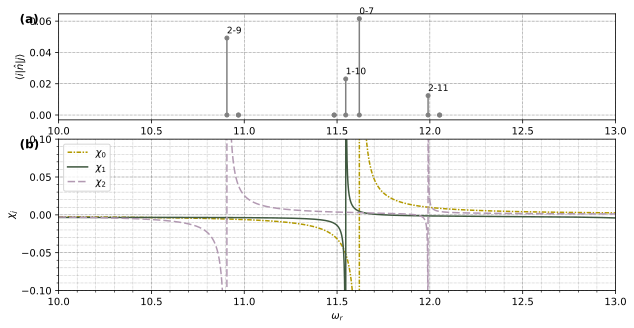

In [25]:



n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 1,EL = 4/18.8, cutoff = 110,flux = 0,truncated_dim=20)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(10,13,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))

plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 77251.70it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_38063/2862248491.py: 55

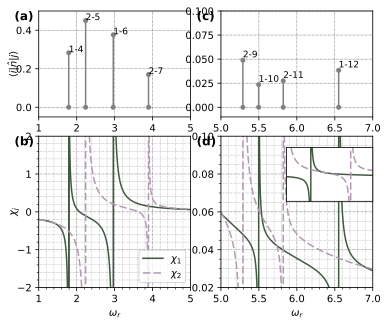

In [160]:
n_evals = 20

qbt = scqubits.Fluxonium(EJ = 2,EC = 0.5,EL = 2/20, cutoff = 110,flux = 0,truncated_dim=20)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)


fig = plt.figure(figsize=(6, 5)) 
gs = gridspec.GridSpec(2, 2, height_ratios=[0.7, 1], hspace=0.15)


Er_list = np.linspace(1,5,int(1e4))
plot_fluxonium_transitions(plt.subplot(gs[0,0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]),ylim = (-0.05,0.5),qls = [1,2],)
plot_sweep_Er(plt.subplot(gs[1,0]), elements,eigenvals,Er_list,qls = [1,2],ylim=(-2,2),
            #   participating_transitions = [(0,7),(1,10),(1,12),(2,9),(2,11)])
            participating_transitions = [(0,1),(0,3),(0,5),
                                        (1,0),(1,2),(1,4),(1,6),
                                         (2,3),(2,5),(2,7)])

elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(5,7,int(1e4))
plot_fluxonium_transitions(plt.subplot(gs[0,1]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]),ylim = (-0.01,0.1),qls = [1,2],)
plot_sweep_Er(plt.subplot(gs[1,1]), elements,eigenvals,Er_list,qls = [1,2],ylim=(0.02,0.1),
              participating_transitions = [(0,7),(1,10),(1,12),(2,9),(2,11),
                                           (0,1),(0,3),(0,5),
                                        (1,0),(1,2),(1,4),(1,6),
                                         (2,3),(2,5),(2,7)])


plt.text(-0.16, 1, '(a)', transform=plt.subplot(gs[0,0]).transAxes, fontsize=12, fontweight='bold', va='top', color='black')
plt.text(-0.16, 1, '(b)', transform=plt.subplot(gs[1,0]).transAxes, fontsize=12, fontweight='bold', va='top', color='black')
plt.text(-0.16, 1, '(c)', transform=plt.subplot(gs[0,1]).transAxes, fontsize=12, fontweight='bold', va='top', color='black')
plt.text(-0.16, 1, '(d)', transform=plt.subplot(gs[1,1]).transAxes, fontsize=12, fontweight='bold', va='top', color='black')


plt.subplot(gs[1,0]).yaxis.set_label_coords(-0.13, 0.5)
plt.subplot(gs[1,0]).set_ylabel(r'$\chi_{j}$')
plt.subplot(gs[1,0]).legend(loc = 'lower right')


plt.subplot(gs[0,0]).set_ylabel(r'$\langle i | \hat{n} | j \rangle$')
plt.subplot(gs[0,0]).yaxis.set_label_coords(-0.13, 0.5)


left, bottom, width, height = [0.7, 0.35, 0.2, 0.15]
inset_ax = fig.add_axes([left, bottom, width, height])
Er_list = np.linspace(5.3,6,int(1e4))
plot_sweep_Er(inset_ax, elements,eigenvals,Er_list,qls = [1,2],ylim=(-0.05,0.05),
              participating_transitions = [(0,7),(1,10),(1,12),(2,9),(2,11),
                                           ])
inset_ax.set_xticks([],[])
inset_ax.set_yticks([],[])
inset_ax.set_xlabel('')

plt.tight_layout()
plt.show()

fig.savefig('chi1chi2.pdf')


Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 40151.10it/s]
 /tmp/ipykernel_660913/1625380249.py: 12

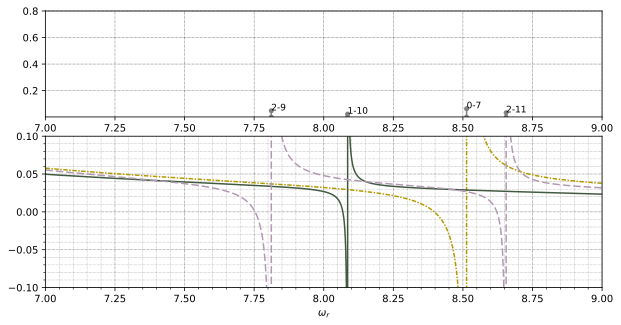

In [4]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.5, cutoff = 110,flux = 0,truncated_dim=20)
n_evals = 40
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(7,9,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))

plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 44644.24it/s]
 /tmp/ipykernel_660913/16555710.py: 12

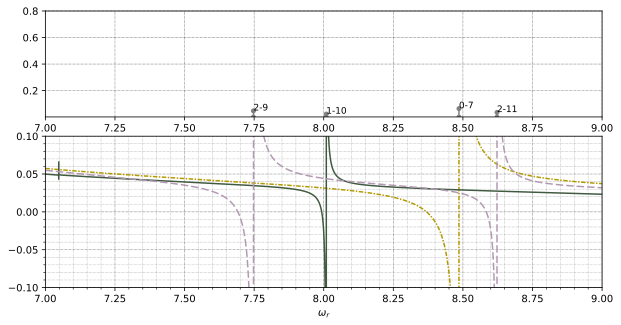

In [5]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.75, cutoff = 110,flux = 0,truncated_dim=20)
n_evals = 40
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(7,9,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))

plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 46201.99it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_53874/2718742181.py: 12

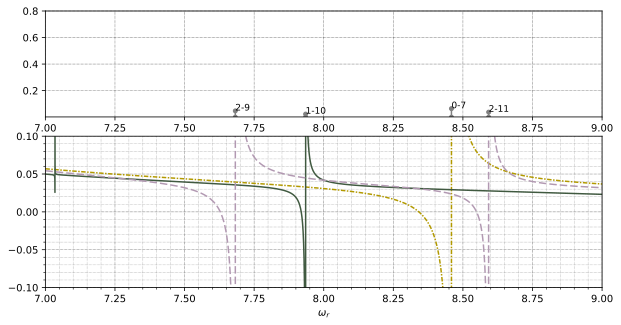

In [34]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/21, cutoff = 110,flux = 0,truncated_dim=20)
n_evals = 40
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(7,9,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))

plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 55659.41it/s]
 /tmp/ipykernel_52688/397630421.py: 12

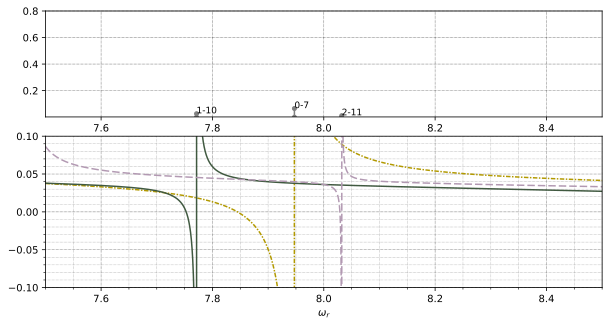

In [8]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4.5833,EL = 3/21.1538, cutoff = 110,flux = 0,truncated_dim=20)
n_evals = 40
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(7.5,8.5,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))

plt.tight_layout()
plt.show()

# What if not at crossovers

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 43853.75it/s]
 /tmp/ipykernel_980616/3942334682.py: 12

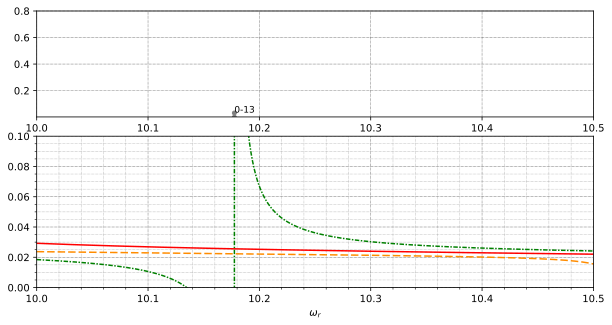

In [17]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/40, cutoff = 110,flux = 0,truncated_dim=20)
n_evals = 40
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(10,10.5,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(0,0.1))

plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 47144.49it/s]
 /tmp/ipykernel_985172/3942334682.py: 12

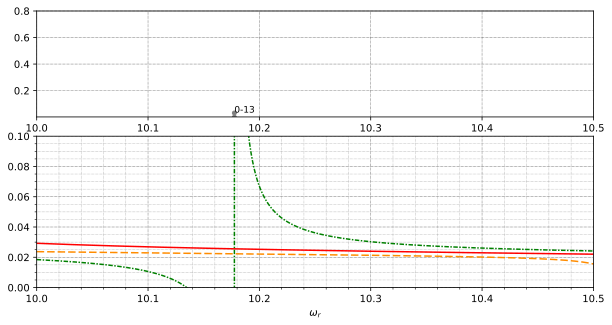

In [8]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/40, cutoff = 110,flux = 0,truncated_dim=20)
n_evals = 40
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(10,10.5,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(0,0.1))

plt.tight_layout()
plt.show()